In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [70]:
# Load the dataset
df = pd.read_csv('stock_market_dataset_converted.csv')

In [71]:
df.head()

,Stock,Date,Open,High,Low,Close,Volume,SMA_10,RSI,MACD,Bollinger_Upper,Bollinger_Lower,GDP_Growth,Inflation_Rate,Interest_Rate,Sentiment_Score,Next_Close,Target
0,AAPL,2010-01-04,445.627510,465.464143,431.513035,450.378213,2441288,301.310351,64.061774,2.449751,464.398638,438.231589,2.845199,1.505217,4.360374,-0.079418,445.714557,0
1,AAPL,2010-01-05,441.194244,449.726464,432.618124,437.397748,4714199,280.015623,52.032235,-3.726473,450.099041,431.018080,3.352677,1.516110,2.309996,0.511900,439.507357,1
2,AAPL,2010-01-07,395.417421,399.413060,385.055059,388.718345,3948217,323.131496,71.817441,-4.215862,396.010670,374.092744,3.471209,2.256823,0.984588,0.049279,387.335810,0
3,AAPL,2010-01-11,478.631057,501.639769,461.991967,484.401144,3637733,273.944016,67.133451,1.574418,496.399599,479.317188,2.962110,2.238436,1.754234,0.737874,476.642532,0
4,AAPL,2010-01-12,179.950904,183.900759,175.076588,181.516782,693492,237.354447,84.797294,1.552505,189.479672,171.610610,2.727858,2.378014,2.562107,-0.905092,182.863272,1


In [72]:
df.tail()

,Stock,Date,Open,High,Low,Close,Volume,SMA_10,RSI,MACD,Bollinger_Upper,Bollinger_Lower,GDP_Growth,Inflation_Rate,Interest_Rate,Sentiment_Score,Next_Close,Target
50344,TSLA,2202-12-01,252.632973,255.849960,246.056470,253.503707,4231791,308.690354,52.049065,0.006139,263.440844,244.288946,3.139296,2.056435,2.671630,0.859307,248.582750,0
50345,TSLA,2202-12-09,144.930034,149.742444,136.559836,142.888733,3163615,251.171784,69.407608,3.285598,156.125748,135.966587,2.904545,1.660142,2.454363,-0.036178,141.163357,0
50346,TSLA,2202-12-13,309.154585,318.731779,300.264935,310.458377,4277458,261.636379,46.411470,-3.419487,322.696934,299.873656,3.148182,2.483237,2.008409,0.915237,310.223950,0
50347,TSLA,2202-12-15,195.542188,198.632883,191.095971,193.650255,1049336,276.348336,28.515595,-2.786398,198.772974,184.331390,2.671756,1.795277,4.345577,-0.836666,190.725552,0
50348,TSLA,2202-12-21,416.282948,425.741095,406.045217,410.052198,3980102,274.376780,44.355109,-3.663012,415.553315,396.362481,2.656378,2.027740,2.853118,-0.943439,409.745233,0


In [73]:
# 1. Basic Information & Data Cleaning
print("--- Dataset Info ---")
print(df.info())

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50349 entries, 0 to 50348
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Stock            50349 non-null  object 
 1   Date             50349 non-null  object 
 2   Open             50349 non-null  float64
 3   High             50349 non-null  float64
 4   Low              50349 non-null  float64
 5   Close            50349 non-null  float64
 6   Volume           50349 non-null  int64  
 7   SMA_10           50349 non-null  float64
 8   RSI              50349 non-null  float64
 9   MACD             50349 non-null  float64
 10  Bollinger_Upper  50349 non-null  float64
 11  Bollinger_Lower  50349 non-null  float64
 12  GDP_Growth       50349 non-null  float64
 13  Inflation_Rate   50349 non-null  float64
 14  Interest_Rate    50349 non-null  float64
 15  Sentiment_Score  50349 non-null  float64
 16  Next_Close       50349 non-null  floa

In [74]:
# Convert Date to datetime objects
df['Date'] = pd.to_datetime(df['Date'])

In [75]:
# Check for missing values
print("\n--- Missing Values ---")
print(df.isnull().sum())


--- Missing Values ---
Stock              0
Date               0
Open               0
High               0
Low                0
Close              0
Volume             0
SMA_10             0
RSI                0
MACD               0
Bollinger_Upper    0
Bollinger_Lower    0
GDP_Growth         0
Inflation_Rate     0
Interest_Rate      0
Sentiment_Score    0
Next_Close         0
Target             0
dtype: int64


In [76]:
# 2. Statistical Summary
print("\n--- Descriptive Statistics ---")
print(df.describe())


--- Descriptive Statistics ---
                                Date          Open          High  \
count                          50349  50349.000000  50349.000000   
mean   2106-08-25 11:03:14.554012672    274.949818    281.765893   
min              2010-01-04 00:00:00     49.106664     50.227411   
25%              2058-05-29 00:00:00    162.088317    166.265621   
50%              2106-04-12 00:00:00    274.928366    281.961442   
75%              2154-11-05 00:00:00    386.653578    396.218846   
max              2202-12-27 00:00:00    509.361090    524.861970   
std                              NaN    129.861782    133.040144   

                Low         Close        Volume        SMA_10           RSI  \
count  50349.000000  50349.000000  5.034900e+04  50349.000000  50349.000000   
mean     268.061694    274.924734  2.547134e+06    274.910267     49.827072   
min       47.755292     50.078817  1.000890e+05     91.000865     10.000911   
25%      158.015601    162.105889  1.32

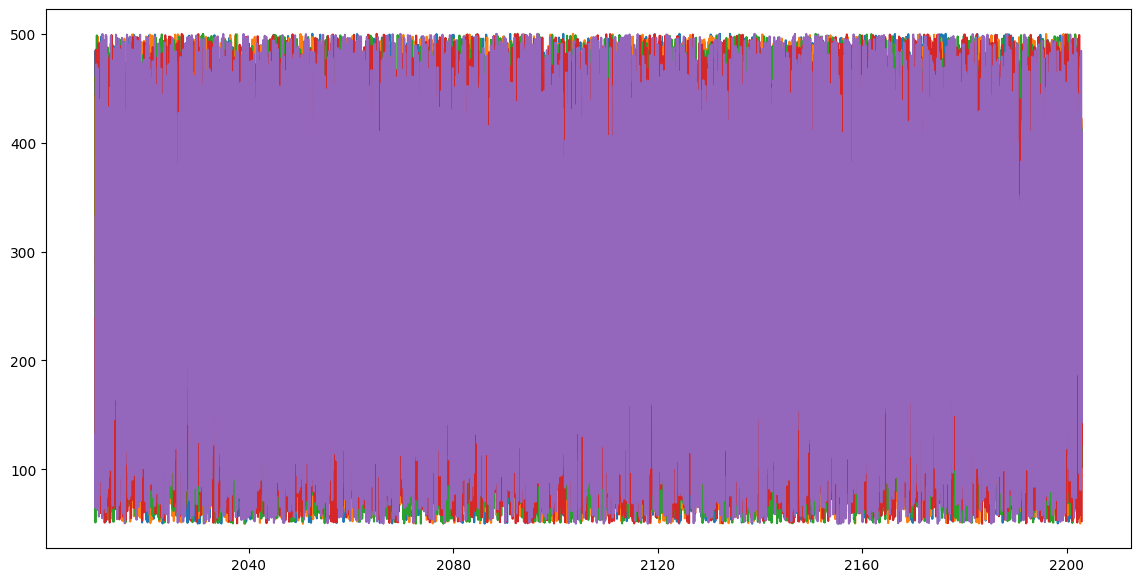

In [77]:
# 3. Visualizing Stock Price Trends
plt.figure(figsize=(14, 7))
for stock in df['Stock'].unique():
    subset = df[df['Stock'] == stock]
    plt.plot(subset['Date'], subset['Close'], label=stock)

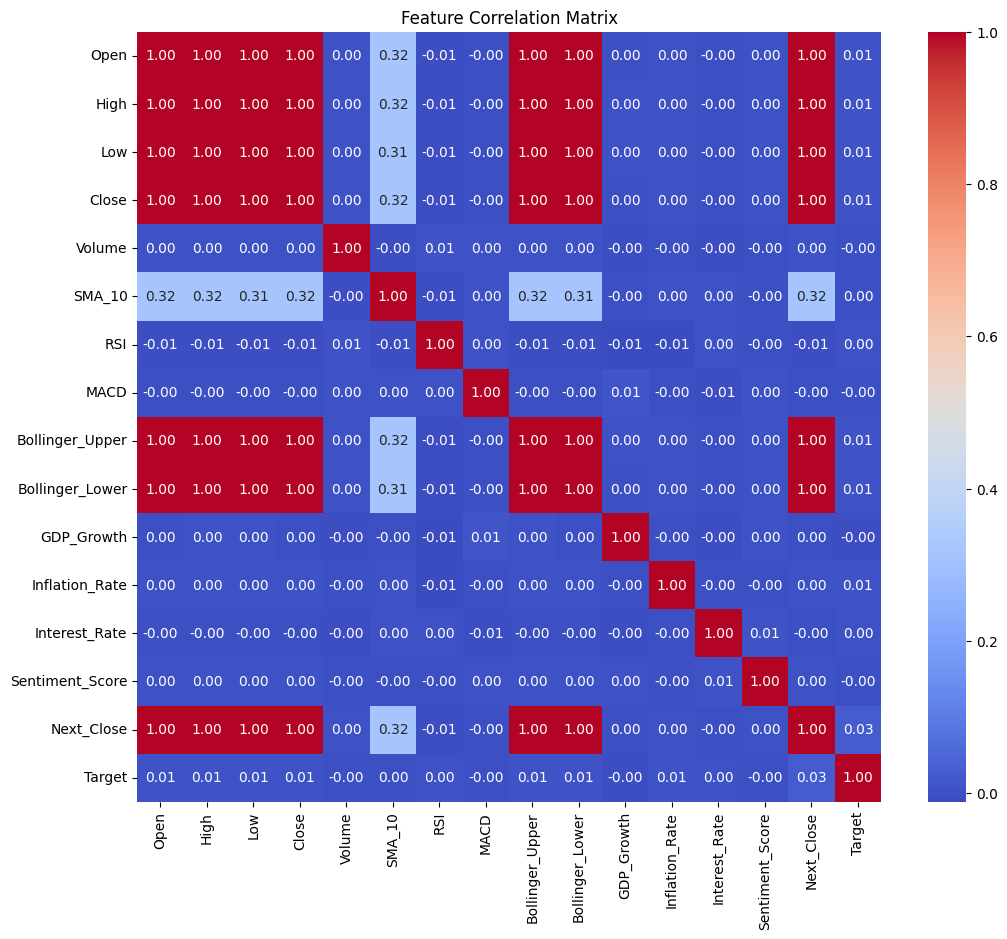

In [78]:
# 4. Correlation Heatmap
# We drop non-numeric columns for the correlation matrix
plt.figure(figsize=(12, 10))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Matrix')
plt.show()

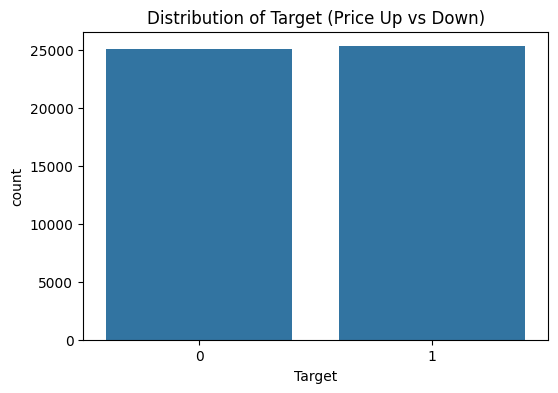

In [79]:
# 5. Distribution of Target Variable
plt.figure(figsize=(6, 4))
sns.countplot(x='Target', data=df)
plt.title('Distribution of Target (Price Up vs Down)')
plt.show()

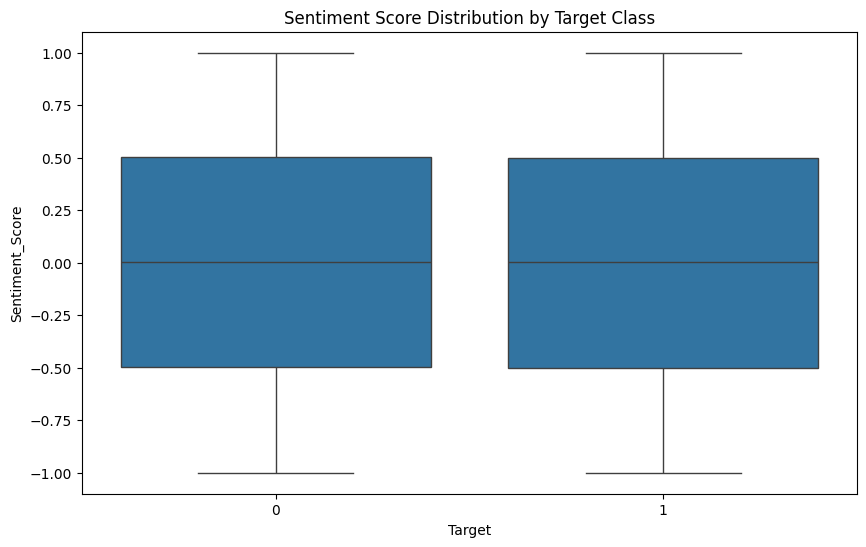

In [80]:
# 6. Sentiment vs Price Change
plt.figure(figsize=(10, 6))
sns.boxplot(x='Target', y='Sentiment_Score', data=df)
plt.title('Sentiment Score Distribution by Target Class')
plt.show()

In [81]:
df.describe()

,Date,Open,High,Low,Close,Volume,SMA_10,RSI,MACD,Bollinger_Upper,Bollinger_Lower,GDP_Growth,Inflation_Rate,Interest_Rate,Sentiment_Score,Next_Close,Target
count,50349,50349.000000,50349.000000,50349.000000,50349.000000,5.034900e+04,50349.000000,50349.000000,50349.000000,50349.000000,50349.000000,50349.000000,50349.000000,50349.000000,50349.000000,50349.000000,50349.000000
mean,2106-08-25 11:03:14.554012672,274.949818,281.765893,268.061694,274.924734,2.547134e+06,274.910267,49.827072,0.007013,284.924427,264.916157,3.000355,2.250040,2.746320,0.001429,274.943789,0.501976
min,2010-01-04 00:00:00,49.106664,50.227411,47.755292,50.078817,1.000890e+05,91.000865,10.000911,-4.999912,55.160167,35.759134,2.500040,1.500009,0.500014,-0.999921,49.443977,0.000000
25%,2058-05-29 00:00:00,162.088317,166.265621,158.015601,162.105889,1.321219e+06,247.286597,29.847647,-2.511063,172.264659,152.149801,2.750128,1.871944,1.626444,-0.499875,162.272760,0.000000
50%,2106-04-12 00:00:00,274.928366,281.961442,268.121257,275.005601,2.546261e+06,274.911668,49.906363,0.011629,285.012100,264.655584,2.999740,2.251659,2.746131,0.004065,275.056340,1.000000
75%,2154-11-05 00:00:00,386.653578,396.218846,376.748125,386.636207,3.767910e+06,302.526785,69.821850,2.516192,396.673124,376.636601,3.250861,2.624896,3.862460,0.499449,386.790854,1.000000
max,2202-12-27 00:00:00,509.361090,524.861970,499.339660,499.962629,4.999977e+06,438.897688,89.999704,4.999610,514.789524,494.472084,3.499968,2.999991,4.999880,0.999966,509.341161,1.000000
std,NaN,129.861782,133.040144,126.627094,129.786177,1.413136e+06,40.732721,23.097843,2.887802,129.831090,129.825109,0.289456,0.433514,1.297482,0.577099,129.855561,0.500001


In [82]:
total_duplicates = df.duplicated().sum()
print(f"Total duplicate rows: {total_duplicates}")

Total duplicate rows: 0


In [83]:
print("\n--- Unique Values Per Column ---")
# This creates a summary table of unique counts and data types
unique_summary = pd.DataFrame({
    'Unique Values': df.nunique(),
    'Data Type': df.dtypes,
    'Sample Values': [df[col].unique()[:3] for col in df.columns] # Shows the first 3 unique entries
})
print(unique_summary)


--- Unique Values Per Column ---
                 Unique Values       Data Type  \
Stock                        5          object   
Date                     31776  datetime64[ns]   
Open                     50349         float64   
High                     50349         float64   
Low                      50349         float64   
Close                    50349         float64   
Volume                   50093           int64   
SMA_10                   50349         float64   
RSI                      50349         float64   
MACD                     50349         float64   
Bollinger_Upper          50349         float64   
Bollinger_Lower          50349         float64   
GDP_Growth               50349         float64   
Inflation_Rate           50349         float64   
Interest_Rate            50349         float64   
Sentiment_Score          50349         float64   
Next_Close               50349         float64   
Target                       2           int64   

               

In [84]:
# 3. Specific Categorical Check
# Checking how many unique stock tickers are in the dataset
print("\n--- Unique Stocks Tickers ---")
print(df['Stock'].unique())


--- Unique Stocks Tickers ---
['AAPL' 'AMZN' 'GOOG' 'MSFT' 'TSLA']


In [85]:
# 4. Checking for "Near Duplicates"
# Sometimes rows aren't identical but share the same Ticker and Date
date_ticker_dupes = df.duplicated(subset=['Stock', 'Date']).sum()
print(f"\nRows with identical Stock and Date: {date_ticker_dupes}")


Rows with identical Stock and Date: 4684


In [86]:
# Check for negative prices or volume
negative_cols = ['Open', 'High', 'Low', 'Close', 'Volume']
garbage_found = (df[negative_cols] < 0).any().any()
print(f"Negative values found: {garbage_found}")

# Check for RSI logical errors
rsi_errors = df[(df['RSI'] < 0) | (df['RSI'] > 100)]
print(f"RSI out of range count: {len(rsi_errors)}")

# Check for invalid Target values
invalid_targets = df[~df['Target'].isin([0, 1])]
print(f"Invalid target values count: {len(invalid_targets)}")

Negative values found: False
RSI out of range count: 0
Invalid target values count: 0


In [87]:
from sklearn.preprocessing import StandardScaler
# 1. Feature Engineering
# Convert Date to datetime and sort to ensure time-series integrity
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(by=['Stock', 'Date'])

# A. Momentum/Lag Features: Give the model a 'memory' of the previous day
df['Close_Lag_1'] = df.groupby('Stock')['Close'].shift(1)
df['Volume_Lag_1'] = df.groupby('Stock')['Volume'].shift(1)

# B. Volatility: Calculate daily percentage change
df['Daily_Return'] = df.groupby('Stock')['Close'].pct_change()

# C. Temporal Features: Help the model identify seasonal or weekly patterns
df['Month'] = df['Date'].dt.month
df['DayOfWeek'] = df['Date'].dt.dayofweek

# D. Convergence/Divergence: Check price position relative to moving average
df['Price_to_SMA'] = df['Close'] / df['SMA_10']

# Drop the first row of each stock (which now contain NaNs from lagging)
df_final = df.dropna().copy()

# 2. Normalization (Standardization)
# We scale features so the model isn't biased by large numbers like 'Volume'
exclude_cols = ['Stock', 'Date', 'Target', 'Next_Close']
cols_to_scale = [col for col in df_final.columns if col not in exclude_cols]

scaler = StandardScaler()
df_final[cols_to_scale] = scaler.fit_transform(df_final[cols_to_scale])

# Save the ready-to-train dataset
df_final.to_csv('engineered_stock_data.csv', index=False)

print("Feature engineering complete. New shape:", df_final.shape)
print("\nNew features added: Close_Lag_1, Volume_Lag_1, Daily_Return, Month, DayOfWeek, Price_to_SMA")

Feature engineering complete. New shape: (50344, 24)

New features added: Close_Lag_1, Volume_Lag_1, Daily_Return, Month, DayOfWeek, Price_to_SMA


In [88]:
df.isnull().sum()

,0
Stock,0
Date,0
Open,0
High,0
Low,0
Close,0
Volume,0
SMA_10,0
RSI,0
MACD,0


In [89]:
# List of features to keep, excluding low-impact and 'Next_Close' (leakage)
# 'Stock' and 'Date' are also excluded as they are non-numeric identifiers
features_to_remove = ['Stock', 'Date', 'Volume', 'Next_Close', 'Target']
X = df.drop(columns=features_to_remove)
y = df['Target']

# Retrain the XGBoost model with the refined feature set
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = XGBClassifier()
model.fit(X_train, y_train)

# Evaluate the new accuracy
new_accuracy = model.score(X_test, y_test)
print(f"New XGBoost Accuracy: {new_accuracy * 100:.2f}%")

New XGBoost Accuracy: 50.07%


In [90]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# Load your dataset
df = pd.read_csv('stock_market_dataset_converted.csv')

# 1. Feature Selection
# We remove 'Stock' and 'Date' as they are non-numeric identifiers.
# 'Next_Close' is removed because it's the regression target, not for classification.
X = df.drop(columns=['Stock', 'Date', 'Target', 'Next_Close'])
y = df['Target']

# 2. 80:20 Train-Test Split
# IMPORTANT: For stock data, we set shuffle=False to maintain chronological order.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, shuffle=False
)

# 3. Model Initialization & Training
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 4. Model Evaluation
y_pred = model.predict(X_test)
print(f"Model Accuracy: {accuracy_score(y_test, y_pred):.2%}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Model Accuracy: 49.67%

Classification Report:
               precision    recall  f1-score   support

           0       0.49      0.51      0.50      4978
           1       0.50      0.48      0.49      5092

    accuracy                           0.50     10070
   macro avg       0.50      0.50      0.50     10070
weighted avg       0.50      0.50      0.50     10070



In [91]:
import pandas as pd
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

# 1. Data Preparation
df = pd.read_csv('stock_market_dataset_converted.csv')
X = df.drop(columns=['Stock', 'Date', 'Target', 'Next_Close'])
y = df['Target']

# 2. Chronological 80:20 Split
# We avoid shuffling to maintain the time-series order
split_idx = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# 3. Initialize and Train XGBoost
# n_estimators: Number of gradient boosted trees
# learning_rate: Step size shrinkage used to prevent overfitting
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

# 4. Predictions and Results
y_pred = xgb_model.predict(X_test)
print(f"XGBoost Accuracy: {accuracy_score(y_test, y_pred):.2%}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# 5. Identifying Key Market Drivers (Feature Importance)
importances = pd.Series(xgb_model.feature_importances_, index=X.columns)
print("\nTop 5 Influential Features:\n", importances.sort_values(ascending=False).head(5))

XGBoost Accuracy: 50.30%

Classification Report:
               precision    recall  f1-score   support

           0       0.50      0.48      0.49      4978
           1       0.51      0.52      0.52      5092

    accuracy                           0.50     10070
   macro avg       0.50      0.50      0.50     10070
weighted avg       0.50      0.50      0.50     10070


Top 5 Influential Features:
 Close              0.081097
Bollinger_Lower    0.079774
Low                0.075438
High               0.073862
GDP_Growth         0.072132
dtype: float32


In [ ]:
import pandas as pd
import numpy as np

# Load and sort data by date to ensure chronological order
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(['Stock', 'Date'])

# 1. Create Lagged Features (e.g., previous 3 days of closing prices)
for lag in [1, 3, 5]:
    df[f'Close_lag_{lag}'] = df.groupby('Stock')['Close'].shift(lag)

# 2. Add Volatility (Rolling Standard Deviation)
df['Rolling_Std_10'] = df.groupby('Stock')['Close'].transform(lambda x: x.rolling(window=10).std())

# 3. Daily Returns (Stationary data often performs better)
df['Daily_Return'] = df.groupby('Stock')['Close'].pct_change()

# Drop rows with NaN values created by shifting/rolling
df = df.dropna()

In [69]:
from sklearn.model_selection import TimeSeriesSplit
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

# Prepare features (X) and target (y)
features = ['Open', 'High', 'Low', 'Close', 'Volume', 'SMA_10', 'RSI', 'MACD',
            'Sentiment_Score', 'Close_lag_1', 'Close_lag_3', 'Rolling_Std_10']
X = df[features]
y = df['Target']

# Initialize TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=5)

for train_index, test_index in tscv.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Model with basic hyperparameter adjustments
    model = XGBClassifier(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )

    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    print(f"Fold Accuracy: {accuracy_score(y_test, predictions):.4f}")

KeyError: "['Close_lag_1', 'Close_lag_3', 'Rolling_Std_10'] not in index"

In [ ]:
import pandas as pd
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

# 1. Data Preparation
df = pd.read_csv('stock_market_dataset_converted.csv')
X = df.drop(columns=['Stock', 'Date', 'Target', 'Next_Close'])
y = df['Target']

# 2. Chronological 80:20 Split
# We avoid shuffling to maintain the time-series order
split_idx = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# 3. Initialize and Train XGBoost
# n_estimators: Number of gradient boosted trees
# learning_rate: Step size shrinkage used to prevent overfitting
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

# 4. Predictions and Results
y_pred = xgb_model.predict(X_test)
print(f"XGBoost Accuracy: {accuracy_score(y_test, y_pred):.2%}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# 5. Identifying Key Market Drivers (Feature Importance)
importances = pd.Series(xgb_model.feature_importances_, index=X.columns)
print("\nTop 5 Influential Features:\n", importances.sort_values(ascending=False).head(5))